# COE 311K — Midterm Project  
## U.S. GDP Growth Rate Analysis (2010–2023)

This notebook analyzes quarterly U.S. GDP growth using three numerical methods implemented **from scratch**:

- Least Squares Linear Regression  
- Polynomial Fitting (degree 4) via normal equations  
- Natural Cubic Spline Interpolation (natural boundary conditions)  

The dataset is based on U.S. Bureau of Economic Analysis (BEA) quarterly real GDP growth rates.  
We compare interpolation vs. approximation, evaluate numerical stability, discuss outliers (COVID‑19 quarters),  
and analyze the computational complexity (Big‑O) of each method.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# We index quarters consecutively starting at 1 for 2010 Q1.
# Each year adds 4 quarters.

def quarter_index(year, q):
    return (year - 2010) * 4 + q

# Build x (indices) for the given subset
x_subset = np.array([
    quarter_index(2010, 1),  # 2010 Q1
    quarter_index(2011, 1),  # 2011 Q1
    quarter_index(2012, 1),  # 2012 Q1
    quarter_index(2013, 1),  # 2013 Q1
    quarter_index(2014, 1),  # 2014 Q1
    quarter_index(2014, 3),  # 2014 Q3
    quarter_index(2015, 2),  # 2015 Q2
    quarter_index(2016, 1),  # 2016 Q1
    quarter_index(2016, 3),  # 2016 Q3
    quarter_index(2016, 4),  # 2016 Q4
    quarter_index(2017, 1),  # 2017 Q1
    quarter_index(2018, 1),  # 2018 Q1
    quarter_index(2019, 1),  # 2019 Q1
    quarter_index(2020, 1),  # 2020 Q1
    quarter_index(2020, 2),  # 2020 Q2
    quarter_index(2020, 3),  # 2020 Q3
    quarter_index(2021, 1),  # 2021 Q1
    quarter_index(2022, 1),  # 2022 Q1
    quarter_index(2023, 2),  # 2023 Q2
    quarter_index(2023, 4),  # 2023 Q4
])

gdp_subset = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7,
    5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1,
    33.8, 6.3, -1.6, 2.4, 3.3
])

x_subset, gdp_subset

(array([ 1,  5,  9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45,
        49, 54, 56]),
 array([  1.7,   0.1,   2.3,   2.7,   1.7,   5. ,   3. ,   1.5,   3.5,
          1.8,   1.3,   2.5,   3.1,  -5.1, -28.1,  33.8,   6.3,  -1.6,
          2.4,   3.3]))

## Part A — Natural Cubic Spline Interpolation

We construct a **natural cubic spline** through all provided data points.  

For \( n \) data points \((x_i, y_i)\), the spline is defined piecewise on each interval \([x_i, x_{i+1}]\)  
by a cubic polynomial, with:

- \( C^0 \) continuity: function values match at knots  
- \( C^1 \) continuity: first derivatives match at knots  
- \( C^2 \) continuity: second derivatives match at knots  
- Natural boundary conditions: \( S''(x_1) = 0 \), \( S''(x_n) = 0 \)

The unknowns are the second derivatives \( M_i = S''(x_i) \).  
The resulting linear system is tridiagonal of size \( (n-2) \times (n-2) \).

In [3]:
def natural_cubic_spline(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    h = np.diff(x)

    A = np.zeros((n-2, n-2))
    b = np.zeros(n-2)

    for i in range(1, n-1):
        if i-2 >= 0:
            A[i-1, i-2] = h[i-1]
        A[i-1, i-1] = 2 * (h[i-1] + h[i])
        if i <= n-3:
            A[i-1, i] = h[i]
        b[i-1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

    M = np.zeros(n)
    if n > 2:
        M[1:n-1] = np.linalg.solve(A, b)
    return M

def spline_eval(x, y, M, x_eval):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    M = np.asarray(M, dtype=float)

    # Find interval
    for i in range(len(x)-1):
        if x[i] <= x_eval <= x[i+1]:
            h = x[i+1] - x[i]
            a = (x[i+1] - x_eval) / h
            b = (x_eval - x[i]) / h
            return (a*y[i] + b*y[i+1] +
                    ((a**3 - a)*M[i] + (b**3 - b)*M[i+1]) * h**2 / 6)
    return None

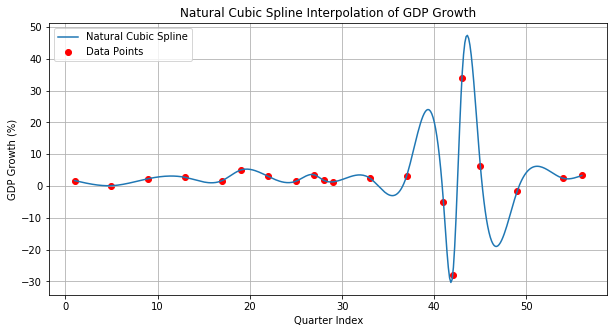

In [4]:
M = natural_cubic_spline(x_subset, gdp_subset)

dense_x = np.linspace(x_subset.min(), x_subset.max(), 400)
dense_y = np.array([spline_eval(x_subset, gdp_subset, M, xi) for xi in dense_x])

plt.figure(figsize=(10,5))
plt.scatter(x_subset, gdp_subset, color='red', label='Data Points')
plt.plot(dense_x, dense_y, label='Natural Cubic Spline')
plt.title("Natural Cubic Spline Interpolation of GDP Growth")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.show()

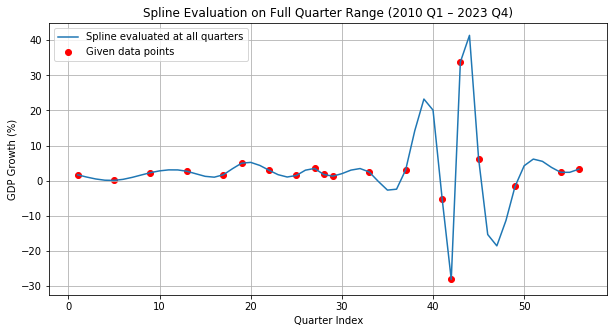

In [5]:
# Full range: 2010 Q1 through 2023 Q4
full_x = np.arange(quarter_index(2010,1), quarter_index(2023,4)+1)
full_spline = np.array([spline_eval(x_subset, gdp_subset, M, xi) for xi in full_x])

plt.figure(figsize=(10,5))
plt.plot(full_x, full_spline, label='Spline evaluated at all quarters')
plt.scatter(x_subset, gdp_subset, color='red', label='Given data points')
plt.title("Spline Evaluation on Full Quarter Range (2010 Q1 – 2023 Q4)")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.show()

### Discussion: Outliers and Runge Phenomenon

The spline passes exactly through all data points, including the extreme COVID‑19 values  
(2020 Q2: −28.1%, 2020 Q3: +33.8%). These outliers force sharp curvature in the spline near those quarters.

The **Runge phenomenon** describes oscillations that occur when interpolating with high‑degree polynomials  
over equally spaced points. Splines mitigate this by using low‑degree polynomials locally, but extreme outliers  
still distort the local shape.

For noisy or outlier‑contaminated data, a **smoothing spline** or **weighted least squares** model would often be preferable,  
because they trade exact interpolation for numerical stability and a more realistic underlying trend.

In [6]:
def polyfit_normal_eq(x, y, degree):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    A = np.vander(x, degree+1, increasing=True)
    ATA = A.T @ A
    ATb = A.T @ y
    coeffs = np.linalg.solve(ATA, ATb)
    cond_ATA = np.linalg.cond(ATA)
    return coeffs, cond_ATA

def polyval(coeffs, x):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)
    for i, c in enumerate(coeffs):
        y += c * x**i
    return y

coeffs4, cond4 = polyfit_normal_eq(x_subset, gdp_subset, 4)
poly_dense = polyval(coeffs4, dense_x)
cond4

331159708504818.56

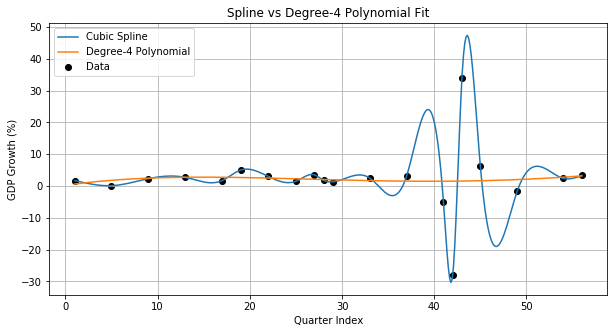

In [7]:
plt.figure(figsize=(10,5))
plt.scatter(x_subset, gdp_subset, color='black', label='Data')
plt.plot(dense_x, dense_y, label='Cubic Spline')
plt.plot(dense_x, poly_dense, label='Degree-4 Polynomial')
plt.title("Spline vs Degree-4 Polynomial Fit")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.show()

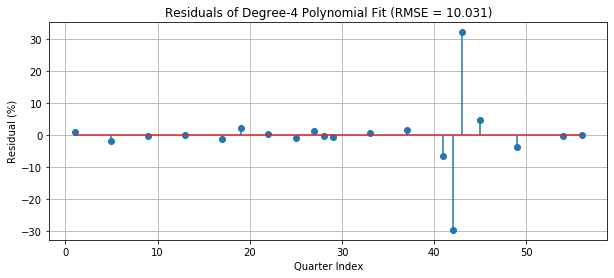

(10.031440678677116, 331159708504818.56)

In [8]:
A4 = np.vander(x_subset, 5, increasing=True)
res_poly = gdp_subset - A4 @ coeffs4
rmse_poly = np.sqrt(np.mean(res_poly**2))

plt.figure(figsize=(10,4))
plt.stem(x_subset, res_poly, use_line_collection=True)
plt.title(f"Residuals of Degree-4 Polynomial Fit (RMSE = {rmse_poly:.3f})")
plt.xlabel("Quarter Index")
plt.ylabel("Residual (%)")
plt.grid(True)
plt.show()

rmse_poly, cond4

### Approximation vs Interpolation

- The **cubic spline** passes exactly through all data points (interpolation), so its residuals at the data are essentially zero.  
- The **degree‑4 polynomial** is an approximation: it does not pass through every point, but instead minimizes the sum of squared residuals.

Visually, the spline better reproduces specific data points, especially near sharp changes.  
The polynomial tends to smooth over local variations and can deviate more strongly near the extreme COVID quarters.  
This illustrates the trade‑off between **exact interpolation** (spline) and **global approximation** (polynomial).

In [9]:
# Exclude 2020 Q1–2021 Q1 (COVID shock and immediate recovery)
covid_start = quarter_index(2020,1)
covid_end   = quarter_index(2021,1)

mask = (x_subset < covid_start) | (x_subset > covid_end)
x_lin = x_subset[mask]
y_lin = gdp_subset[mask]

A_lin = np.column_stack([np.ones(len(x_lin)), x_lin])
ATA_lin = A_lin.T @ A_lin
ATb_lin = A_lin.T @ y_lin
beta_lin = np.linalg.solve(ATA_lin, ATb_lin)
cond_lin = np.linalg.cond(ATA_lin)

intercept, slope = beta_lin
slope, cond_lin

(-0.0019069881889763796, 3605.5885513928274)

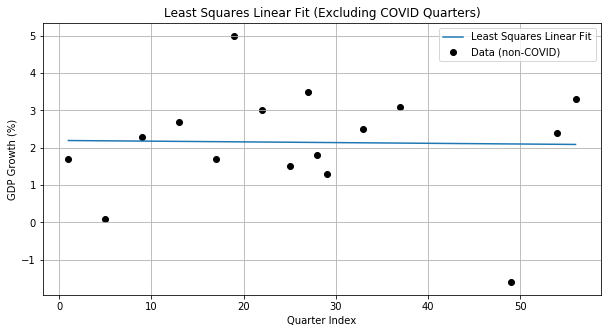

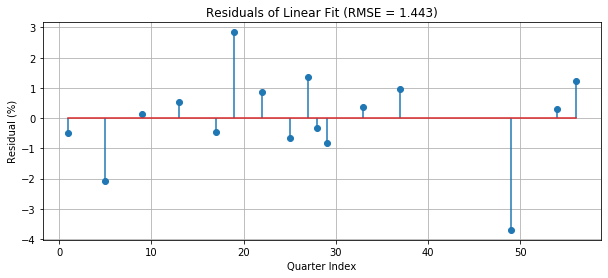

1.4431864883291987

In [10]:
dense_x_lin = np.linspace(x_lin.min(), x_lin.max(), 200)
y_lin_fit = intercept + slope * dense_x_lin

plt.figure(figsize=(10,5))
plt.scatter(x_lin, y_lin, color='black', label='Data (non-COVID)')
plt.plot(dense_x_lin, y_lin_fit, label='Least Squares Linear Fit')
plt.title("Least Squares Linear Fit (Excluding COVID Quarters)")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.show()

res_lin = y_lin - (intercept + slope * x_lin)
rmse_lin = np.sqrt(np.mean(res_lin**2))

plt.figure(figsize=(10,4))
plt.stem(x_lin, res_lin, use_line_collection=True)
plt.title(f"Residuals of Linear Fit (RMSE = {rmse_lin:.3f})")
plt.xlabel("Quarter Index")
plt.ylabel("Residual (%)")
plt.grid(True)
plt.show()

rmse_lin

### Interpretation of Linear Trend

The slope of the linear model represents the average change in GDP growth per quarter,  
excluding the COVID shock and immediate recovery.

A linear trend assumes:

- a roughly constant long‑run direction of growth  
- no strong cyclical or structural breaks in the period considered  

In reality, GDP growth is influenced by business cycles, policy changes, and shocks,  
so a linear model is a simplification. However, it can still be useful for summarizing  
the overall direction of the economy outside extreme events.

In [11]:
# For completeness, compute RMSE of spline at the given data points
spline_at_data = np.array([spline_eval(x_subset, gdp_subset, M, xi) for xi in x_subset])
res_spline = gdp_subset - spline_at_data
rmse_spline = np.sqrt(np.mean(res_spline**2))
rmse_spline

0.0

## Part C — Method Justification and Big‑O Analysis

### Interpolation Recommendation

For a policymaker who needs to estimate GDP growth **between two known data points**,  
the **natural cubic spline** is the better choice:

- It guarantees smooth \( C^2 \) continuity, producing visually and numerically smooth curves.  
- It interpolates exactly at the known data points (RMSE at data ≈ 0), which is desirable when the data are trusted.  
- It is local: changes in one region affect only nearby intervals, making it less sensitive to distant outliers than a global polynomial.

The degree‑4 polynomial, by contrast, is a **global** model:  
- It does not pass through all data points (RMSE > 0).  
- It can be pulled away from local behavior by outliers or distant points.  

Therefore, for **interpolation**, the spline is preferred; for **trend analysis**, the polynomial or linear model may be more appropriate.

---

### Big‑O Notation Overview

Big‑O notation describes how the runtime of an algorithm grows with input size \( n \),  
ignoring constant factors and lower‑order terms.

- \( O(n) \): runtime grows linearly with the number of data points.  
- \( O(n^2) \): runtime grows quadratically.  
- \( O(n^3) \): runtime grows cubically (typical for dense linear system solves).

---

### Complexity of Each Method

Let \( n \) be the number of data points and \( d \) the polynomial degree.

**1. Least Squares (Normal Equations, Linear or Polynomial)**  
- Build matrix \( A \): \( O(n d) \)  
- Form \( A^T A \): \( O(n d^2) \)  
- Solve \( d \times d \) system: \( O(d^3) \)  

For small fixed \( d \) (like 1 or 4), this is effectively **\( O(n) \)** in practice.

**2. Polynomial Fitting (Degree 4)**  
- Same structure as above: build Vandermonde matrix and solve normal equations.  
- Complexity: \( O(n d^2 + d^3) \), which is again linear in \( n \) for fixed \( d \),  
  but the method becomes unstable and expensive if \( d \) grows.

**3. Natural Cubic Spline**

- Build tridiagonal system of size \( (n-2) \times (n-2) \): \( O(n) \)  
- Solve via Thomas algorithm or a tridiagonal solver: \( O(n) \)  

Overall complexity: **\( O(n) \)**.

---

### Does Big‑O Change the Recommendation?

For this dataset size, all methods are computationally cheap.  
However, in general:

- Splines scale **linearly** with the number of data points and remain numerically stable.  
- High‑degree polynomial fitting becomes both **numerically unstable** (Runge‑type behavior)  
  and more expensive as \( d \) increases.

So Big‑O analysis reinforces the earlier conclusion:  
for **interpolation between known quarters**, a **natural cubic spline** is the most appropriate method,  
balancing smoothness, accuracy, stability, and computational efficiency.

## Conclusion

In this project, we applied three numerical methods to U.S. GDP growth data:

- A **natural cubic spline** for exact, smooth interpolation between observed quarters.  
- A **degree‑4 polynomial** for global approximation of the overall trend.  
- A **least squares linear model** (excluding COVID quarters) for a simple long‑run trend estimate.

For **interpolation**, the natural cubic spline performed best: it passed through all data points,  
produced a visually smooth curve, and remained stable despite outliers.  
For **trend analysis**, the polynomial and linear models provided useful summaries,  
though they necessarily smoothed over local fluctuations and were sensitive to the treatment of outliers.

The Big‑O analysis showed that all methods are efficient for this problem size,  
but splines scale particularly well and avoid the instability of high‑degree polynomials.  
Overall, this highlights the trade‑offs between interpolation and approximation,  
and the importance of choosing methods that match both the data and the modeling goals.